In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Input, RepeatVector, TimeDistributed


In [ ]:
milestonedf = pd.DataFrame({
    'player': ['Alice', 'Bob', 'Charlie', 'David', 'Alice'],
    'age': [24, 28, 26, 30, 22],
    'goals': [10, 15, 8, 9, 7],
    'contractyears': [2, 1, 3, 2, 2],
    'goalspast3seasons': [7, 13, 5, 7, 9],
    'injuries': [1, 0, 3, 1, 2],
    'gamesplayed': [25, 34, 22, 30, 25],
    'goaltrend': [0.43, 0.15, 0.60, 0.29, -0.22],
    'injuryrisk': [0.04, 0.0, 0.13, 0.03, 0.08],
    'contractleft': [1, 0, 2, 1, 1],
    'sentimentscore': [0.5, -0.4, 0.0, 0.0, 0.5],
    'expectedmarketvalueboost': [0.75, -0.6, 0.0, 0.0, 0.75]
})

# Make up transfer_value for demonstration
milestonedf['transfer_value'] = milestonedf['goals'] * 1e6 + milestonedf['expectedmarketvalueboost'] * 1e6
display(milestonedf)


,player,age,goals,contractyears,goalspast3seasons,injuries,gamesplayed,goaltrend,injuryrisk,contractleft,sentimentscore,expectedmarketvalueboost,transfer_value
0,Alice,24,10,2,7,1,25,0.43,0.04,1,0.5,0.75,10750000.0
1,Bob,28,15,1,13,0,34,0.15,0.00,0,-0.4,-0.60,14400000.0
2,Charlie,26,8,3,5,3,22,0.60,0.13,2,0.0,0.00,8000000.0
3,David,30,9,2,7,1,30,0.29,0.03,1,0.0,0.00,9000000.0
4,Alice,22,7,2,9,2,25,-0.22,0.08,1,0.5,0.75,7750000.0


In [ ]:
scaler_uni = MinMaxScaler()
uni_features = milestonedf[['goals']].values
uni_target = milestonedf['transfer_value'].values.reshape(-1, 1)
uni_features_scaled = scaler_uni.fit_transform(uni_features)
uni_target_scaled = scaler_uni.fit_transform(uni_target)

X_uni, y_uni = [], []
seq_len = 2  # Sequence length
for i in range(len(uni_features_scaled)-seq_len):
    X_uni.append(uni_features_scaled[i:i+seq_len, :])
    y_uni.append(uni_target_scaled[i+seq_len, 0])
X_uni = np.array(X_uni)
y_uni = np.array(y_uni)

model_uni = Sequential([
    LSTM(32, activation='relu', input_shape=(seq_len, 1)),
    Dense(1)
])
model_uni.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_uni = model_uni.fit(X_uni, y_uni, epochs=30, verbose=0)
uni_pred = model_uni.predict(X_uni)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


In [ ]:
multi_features = milestonedf[['goals', 'injuries', 'sentimentscore']].values
scaler_multi = MinMaxScaler()
multi_features_scaled = scaler_multi.fit_transform(multi_features)
X_multi, y_multi = [], []
for i in range(len(multi_features_scaled)-seq_len):
    X_multi.append(multi_features_scaled[i:i+seq_len, :])
    y_multi.append(uni_target_scaled[i+seq_len, 0])
X_multi = np.array(X_multi)
y_multi = np.array(y_multi)

model_multi = Sequential([
    LSTM(32, activation='relu', input_shape=(seq_len, 3)),
    Dense(1)
])
model_multi.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_multi = model_multi.fit(X_multi, y_multi, epochs=30, verbose=0)
multi_pred = model_multi.predict(X_multi)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


In [ ]:
TIMESTEPS = seq_len
FUTURE_STEPS = 2
X_encdec, y_encdec = [], []
features_encdec = multi_features_scaled
label_encdec = uni_target_scaled[:,0]
for i in range(len(features_encdec) - TIMESTEPS - FUTURE_STEPS + 1):
    X_encdec.append(features_encdec[i:i+TIMESTEPS, :])
    y_encdec.append(label_encdec[i+TIMESTEPS:i+TIMESTEPS+FUTURE_STEPS])
X_encdec = np.array(X_encdec)
y_encdec = np.array(y_encdec)

inputs = Input(shape=(TIMESTEPS, 3))
encoded = LSTM(32, activation='relu')(inputs)
decoded = RepeatVector(FUTURE_STEPS)(encoded)
decoded = LSTM(32, activation='relu', return_sequences=True)(decoded)
outputs = TimeDistributed(Dense(1))(decoded)
model_encdec = Model(inputs, outputs)
model_encdec.compile(optimizer='adam', loss='mse')
history_encdec = model_encdec.fit(X_encdec, y_encdec, epochs=30, verbose=0)
encdec_pred = model_encdec.predict(X_encdec)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step


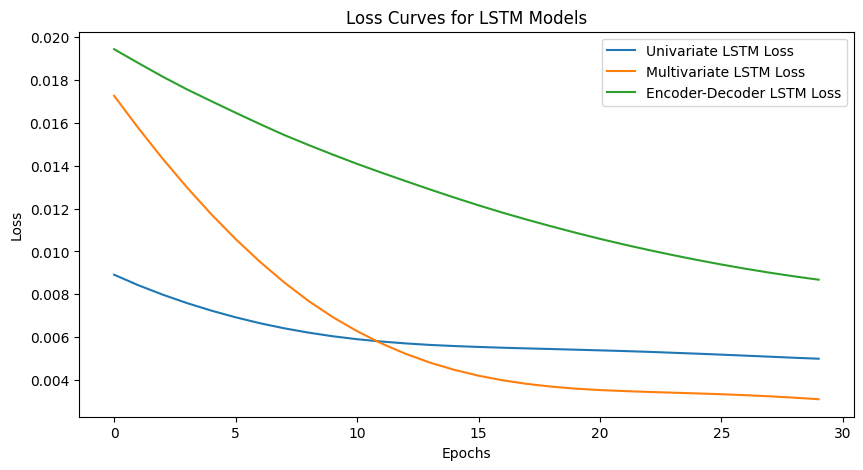

Univariate LSTM - Final Loss: 0.0050, MAE: 0.0687
Multivariate LSTM - Final Loss: 0.0031, MAE: 0.0556
Encoder-Decoder LSTM - Final Loss: 0.0087
Univariate LSTM Predictions (scaled): [0.09818169 0.09625274 0.05258097]
Multivariate LSTM Predictions (scaled): [0.09610612 0.13348135 0.05152662]
Encoder-Decoder Multi-Step Predictions (scaled): [[0.06110088 0.08920259]
 [0.05846129 0.08407129]]


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_uni.history['loss'], label='Univariate LSTM Loss')
plt.plot(history_multi.history['loss'], label='Multivariate LSTM Loss')
plt.plot(history_encdec.history['loss'], label='Encoder-Decoder LSTM Loss')
plt.legend()
plt.title('Loss Curves for LSTM Models')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

print("Univariate LSTM - Final Loss: {:.4f}, MAE: {:.4f}".format(history_uni.history['loss'][-1], history_uni.history['mae'][-1]))
print("Multivariate LSTM - Final Loss: {:.4f}, MAE: {:.4f}".format(history_multi.history['loss'][-1], history_multi.history['mae'][-1]))
print("Encoder-Decoder LSTM - Final Loss: {:.4f}".format(history_encdec.history['loss'][-1]))

print("Univariate LSTM Predictions (scaled):", uni_pred.ravel())
print("Multivariate LSTM Predictions (scaled):", multi_pred.ravel())
print("Encoder-Decoder Multi-Step Predictions (scaled):", encdec_pred.squeeze())
